# 01 - EDA
Estructura, nulos, distribuciones, correlación y colinearidad

In [1]:
# Carga de librerías y dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

# Configuración visual
plt.style.use('seaborn-v0_8')
sns.set_palette('deep')
FIG_DIR = Path('../reports/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Carga del CSV con conversión de marcadores 'NA' a NaN
DATA_PATH = Path('../data/weatherAUS.csv')
na_values = ["NA", "", "?", "NaN", "nan"]
df = pd.read_csv(DATA_PATH, na_values=na_values)
print('Shape inicial:', df.shape)
df.head()

Shape inicial: (145460, 23)


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


### Utilidades auxiliares
Funciones para análisis de faltantes, skew, correlaciones y pares correlacionados.

In [2]:
from scipy import stats
from itertools import combinations

TARGET = 'RainTomorrow'

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.drop(TARGET).tolist()
print(f'Numéricas: {len(numeric_cols)} | Categóricas: {len(cat_cols)}')

def summarize_missing(data: pd.DataFrame):
    miss = data.isna().sum(); miss_pct = miss/len(data)*100
    return (pd.DataFrame({'missing': miss, 'pct': miss_pct})
              .sort_values('pct', ascending=False))

def high_missing_features(data, threshold=30):
    return summarize_missing(data)[lambda d: d['pct']>=threshold]

def plot_missing_bar(data, top=20):
    res = summarize_missing(data).head(top).sort_values('pct')
    plt.figure(figsize=(7,5))
    sns.barplot(x='pct', y=res.index, data=res, palette='viridis')
    plt.xlabel('% Nulos'); plt.ylabel('Variable'); plt.title('Top variables con más nulos')
    plt.tight_layout(); plt.savefig(FIG_DIR / 'eda_missing_top_v2.png', dpi=120); plt.show()

def skew_kurtosis(data, cols=None):
    cols = cols or numeric_cols
    rows = []
    for c in cols:
        series = data[c].dropna()
        if series.empty: continue
        rows.append({'feature': c,
                     'skew': stats.skew(series),
                     'kurtosis': stats.kurtosis(series, fisher=True),
                     'n': len(series)})
    return pd.DataFrame(rows).sort_values('skew', key=lambda s: s.abs(), ascending=False)

def top_correlated_pairs(data, cols=None, threshold=0.8):
    cols = cols or numeric_cols
    corr = data[cols].corr().abs(); pairs = []
    for a,b in combinations(cols,2):
        val = corr.loc[a,b]
        if val >= threshold: pairs.append({'f1': a, 'f2': b, 'corr': val})
    return pd.DataFrame(pairs).sort_values('corr', ascending=False)


Numéricas: 16 | Categóricas: 6


In [5]:
# Dimensiones y tipos
print('Dimensiones (filas, columnas):', df.shape)
print(df.dtypes.value_counts())
df.dtypes

Dimensiones (filas, columnas): (145460, 23)
float64    16
object      7
Name: count, dtype: int64


Date              object
Location          object
MinTemp          float64
MaxTemp          float64
Rainfall         float64
Evaporation      float64
Sunshine         float64
WindGustDir       object
WindGustSpeed    float64
WindDir9am        object
WindDir3pm        object
WindSpeed9am     float64
WindSpeed3pm     float64
Humidity9am      float64
Humidity3pm      float64
Pressure9am      float64
Pressure3pm      float64
Cloud9am         float64
Cloud3pm         float64
Temp9am          float64
Temp3pm          float64
RainToday         object
RainTomorrow      object
dtype: object

In [6]:
# Estadísticas descriptivas
desc = df.describe().T
desc

,count,mean,std,min,25%,50%,75%,max
MinTemp,143975.0,12.194034,6.398495,-8.5,7.6,12.0,16.9,33.9
MaxTemp,144199.0,23.221348,7.119049,-4.8,17.9,22.6,28.2,48.1
Rainfall,142199.0,2.360918,8.478060,0.0,0.0,0.0,0.8,371.0
Evaporation,82670.0,5.468232,4.193704,0.0,2.6,4.8,7.4,145.0
Sunshine,75625.0,7.611178,3.785483,0.0,4.8,8.4,10.6,14.5
WindGustSpeed,135197.0,40.035230,13.607062,6.0,31.0,39.0,48.0,135.0
WindSpeed9am,143693.0,14.043426,8.915375,0.0,7.0,13.0,19.0,130.0
WindSpeed3pm,142398.0,18.662657,8.809800,0.0,13.0,19.0,24.0,87.0
Humidity9am,142806.0,68.880831,19.029164,0.0,57.0,70.0,83.0,100.0
Humidity3pm,140953.0,51.539116,20.795902,0.0,37.0,52.0,66.0,100.0


RainTomorrow
No     110316
Yes     31877
NaN      3267
Name: count, dtype: int64
RainTomorrow
No     75.84
Yes    21.91
NaN     2.25
Name: proportion, dtype: float64


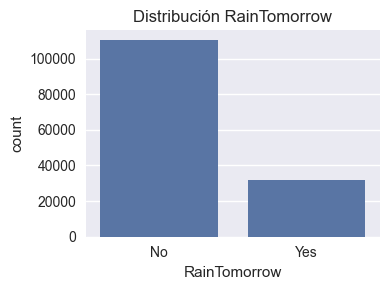

In [7]:
# Distribución de la variable objetivo
# Revisar desbalance que impactará métricas (ej F1, Recall)
print(df['RainTomorrow'].value_counts(dropna=False))
print((df['RainTomorrow'].value_counts(normalize=True, dropna=False)*100).round(2))
plt.figure(figsize=(4,3))
sns.countplot(data=df, x='RainTomorrow')
plt.title('Distribución RainTomorrow')
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_target_distribution.png', dpi=120)
plt.show()

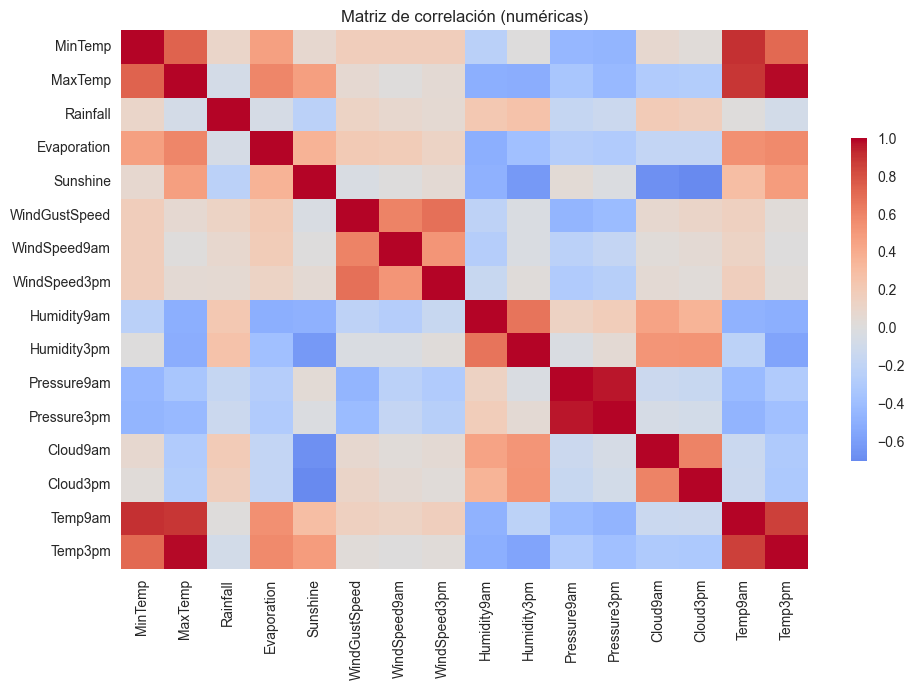

In [8]:
# Matriz de correlación numérica
num_cols = df.select_dtypes(include=[np.number]).columns
corr = df[num_cols].corr()
plt.figure(figsize=(10,7))
sns.heatmap(corr, cmap='coolwarm', center=0, cbar_kws={'shrink':0.6})
plt.title('Matriz de correlación (numéricas)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_correlation_matrix.png', dpi=120)
plt.show()


### Correlaciones y multicolinealidad
Se identifican pares altamente correlacionados y se calcula VIF para orientar eliminación/regularización.

In [11]:
# Pares altamente correlacionados y VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.cluster.hierarchy import linkage, dendrogram

corr_abs = df[num_cols].corr().abs()
# Pares > 0.85
high_pairs = []
for i, c1 in enumerate(num_cols):
    for c2 in num_cols[i+1:]:
        val = corr_abs.loc[c1, c2]
        if val >= 0.85:
            high_pairs.append({'f1': c1, 'f2': c2, 'corr': val})
high_pairs_df = pd.DataFrame(high_pairs).sort_values('corr', ascending=False)
print('Pares con |corr| >= 0.85:')
print(high_pairs_df)

# VIF (usar subset sin nulos excesivos)
# Selecciono variables con <=10% nulos y máximo 15 variables para rapidez
candidate_vif = [c for c in num_cols if df[c].isna().mean() <= 0.10][:15]
X_vif = df[candidate_vif].dropna()
if not X_vif.empty:
    vif_rows = []
    for i, col in enumerate(X_vif.columns):
        try:
            vif_val = variance_inflation_factor(X_vif.values, i)
        except Exception:
            vif_val = np.nan
        vif_rows.append({'feature': col, 'VIF': vif_val})
    vif_df = pd.DataFrame(vif_rows).sort_values('VIF', ascending=False)
    display(vif_df)


Pares con |corr| >= 0.85:
            f1           f2      corr
2      MaxTemp      Temp3pm  0.984503
3  Pressure9am  Pressure3pm  0.961326
0      MinTemp      Temp9am  0.901821
1      MaxTemp      Temp9am  0.887210
4      Temp9am      Temp3pm  0.860591


,feature,VIF
1,MaxTemp,522.778799
9,Temp3pm,514.626735
8,Temp9am,165.100027
6,Humidity9am,47.152152
7,Humidity3pm,36.059497
0,MinTemp,28.809353
3,WindGustSpeed,21.761655
5,WindSpeed3pm,11.733697
4,WindSpeed9am,6.294667
2,Rainfall,1.198063


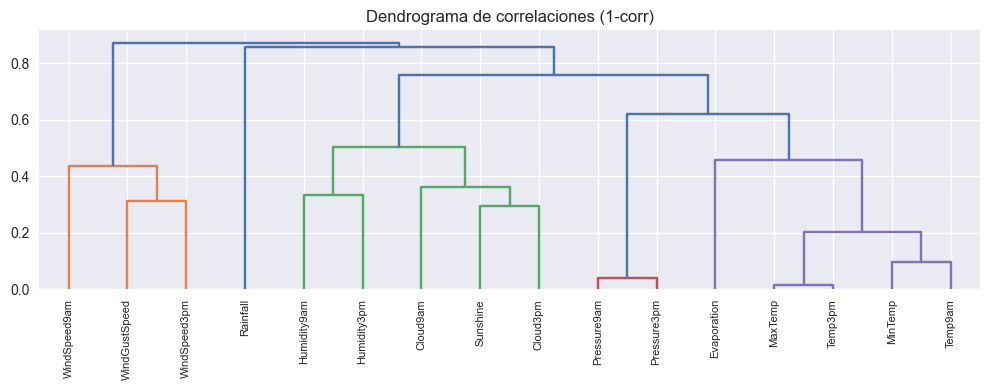

In [12]:
# Clustering de variables numéricas por distancia 1-corr
import scipy.spatial as sps

# Evitar problemas de singularidad eliminando columnas totalmente nulas
valid_corr = corr_abs.dropna(axis=0, how='all').dropna(axis=1, how='all')
# Distancia
distance_matrix = 1 - valid_corr
# Convertir a formato condensado
condensed = sps.distance.squareform(distance_matrix.values, checks=False)
Z = linkage(condensed, method='average')
plt.figure(figsize=(10,4))
dendrogram(Z, labels=valid_corr.columns, leaf_rotation=90, leaf_font_size=8, color_threshold=0.6)
plt.title('Dendrograma de correlaciones (1-corr)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_corr_dendrogram.png', dpi=120)
plt.show()

/var/folders/ks/55574qbd2m13r40rhstrchtr0000gn/T/ipykernel_28149/3418636659.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='pct', y=res.index, data=res, palette='viridis')


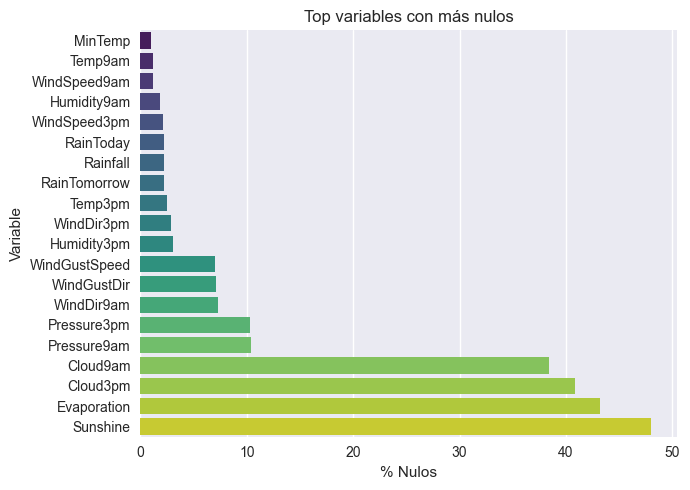

Features con >=30% nulos:


,missing,pct
Sunshine,69835,48.009762
Evaporation,62790,43.166506
Cloud3pm,59358,40.807095
Cloud9am,55888,38.421559


In [13]:
# Visualización y features con alto % de nulos
plot_missing_bar(df, top=20)
print('Features con >=30% nulos:')
high_missing_features(df, 30)


In [14]:
# Sesgo (skew) y curtosis de variables numéricas
sk_df = skew_kurtosis(df)
# Reglas heurísticas: |skew| >1 alto sesgo; 0.5-1 moderado
sk_df['sesgo_categoria'] = pd.cut(sk_df['skew'].abs(), bins=[0,0.5,1,10], labels=['bajo','moderado','alto'], include_lowest=True)
# Sugerencia de transformación
suggestions = []
for _, r in sk_df.iterrows():
    feat = r['feature']
    skew_val = r['skew']
    series = df[feat]
    if series.min() < 0:
        transf = 'Yeo-Johnson (permite negativos)' if abs(skew_val) > 0.8 else 'Considerar estandarizar'
    else:
        if abs(skew_val) > 1:
            transf = 'log1p' if series.min()>=0 else 'Yeo-Johnson'
        elif abs(skew_val) > 0.5:
            transf = 'Quizá sqrt / Box-Cox' if series.min()>0 else 'Yeo-Johnson'
        else:
            transf = 'Sin transformación'
    suggestions.append(transf)
sk_df['transform_sugerida'] = suggestions
sk_df.head(15)

,feature,skew,kurtosis,n,sesgo_categoria,transform_sugerida
2,Rainfall,9.836121,178.145772,142199,alto,log1p
3,Evaporation,3.761218,45.040470,82670,alto,log1p
5,WindGustSpeed,0.874869,1.418545,135197,moderado,Quizá sqrt / Box-Cox
6,WindSpeed9am,0.777621,1.226906,143693,moderado,Yeo-Johnson
7,WindSpeed3pm,0.628209,0.763789,142398,moderado,Yeo-Johnson
4,Sunshine,-0.496470,-0.829484,75625,bajo,Sin transformación
8,Humidity9am,-0.483964,-0.037596,142806,bajo,Sin transformación
15,Temp3pm,0.237958,-0.136319,141851,bajo,Considerar estandarizar
12,Cloud9am,-0.229078,-1.538812,89572,bajo,Sin transformación
13,Cloud3pm,-0.226380,-1.456510,86102,bajo,Sin transformación


In [15]:
# Desbalance de clases: baseline Dummy
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split

base_feats = [c for c in numeric_cols if df[c].isna().sum()==0][:8]
if len(base_feats) < 3:
    base_feats = numeric_cols[:8]

base_df = df.dropna(subset=[TARGET])
X = base_df[base_feats].copy().fillna(base_df[base_feats].median())
y = (base_df[TARGET]=='Yes').astype(int)

if y.nunique() == 2 and len(X) > 100:
    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)
    dummy = DummyClassifier(strategy='most_frequent')
    dummy.fit(X_train, y_train)
    proba = dummy.predict_proba(X_test)[:,1]
    auc_val = roc_auc_score(y_test, proba)
    print('Features baseline:', base_feats)
    print('AUC Dummy:', round(auc_val, 3))
    print(classification_report(y_test, dummy.predict(X_test)))

Features baseline: ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm']
AUC Dummy: 0.5
              precision    recall  f1-score   support

           0       0.78      1.00      0.87     33095
           1       0.00      0.00      0.00      9563

    accuracy                           0.78     42658
   macro avg       0.39      0.50      0.44     42658
weighted avg       0.60      0.78      0.68     42658



/Users/federicogomez/Library/CloudStorage/OneDrive-UniversidadEAFIT/ML en Python/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/federicogomez/Library/CloudStorage/OneDrive-UniversidadEAFIT/ML en Python/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/federicogomez/Library/CloudStorage/OneDrive-UniversidadEAFIT/ML en Python/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined 

In [16]:
# Cuantificación de outliers (IQR) para variables numéricas
outlier_rows = []
for col in numeric_cols:
    series = df[col].dropna()
    if series.empty: continue
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (series < lower) | (series > upper)
    pct = mask.mean() * 100
    outlier_rows.append({'feature': col, 'pct_outliers': pct, 'iqr': iqr, 'q1': q1, 'q3': q3})
outliers_df = pd.DataFrame(outlier_rows).sort_values('pct_outliers', ascending=False)
print('Top 12 variables con mayor % de outliers (def IQR):')
display(outliers_df.head(12))

# Recomendación preliminar de escalado
scaling_rows = []
for _, r in outliers_df.iterrows():
    feat = r['feature']
    pct = r['pct_outliers']
    skew_val = sk_df.loc[sk_df['feature']==feat, 'skew']
    skew_val = float(skew_val) if not skew_val.empty else np.nan
    if pct > 10 or (not np.isnan(skew_val) and abs(skew_val) > 1):
        scaler = 'RobustScaler'
    elif not np.isnan(skew_val) and abs(skew_val) < 0.5 and pct < 5:
        scaler = 'StandardScaler'
    else:
        scaler = 'StandardScaler'
    scaling_rows.append({'feature': feat, 'pct_outliers': round(pct,2), 'skew': round(skew_val,2) if not np.isnan(skew_val) else np.nan, 'scaler_recomendado': scaler})
scaling_map_df = pd.DataFrame(scaling_rows)
print('Mapa de escalado sugerido:')
scaling_map_df

Top 12 variables con mayor % de outliers (def IQR):


,feature,pct_outliers,iqr,q1,q3
2,Rainfall,17.987468,0.8,0.0,0.8
3,Evaporation,2.413209,4.8,2.6,7.4
5,WindGustSpeed,2.287033,17.0,31.0,48.0
7,WindSpeed3pm,1.771795,11.0,13.0,24.0
6,WindSpeed9am,1.264501,12.0,7.0,19.0
8,Humidity9am,0.997857,26.0,57.0,83.0
10,Pressure9am,0.913379,9.5,1012.9,1022.4
11,Pressure3pm,0.704582,9.6,1010.4,1020.0
15,Temp3pm,0.538593,9.8,16.6,26.4
1,MaxTemp,0.339115,10.3,17.9,28.2


Mapa de escalado sugerido:


/var/folders/ks/55574qbd2m13r40rhstrchtr0000gn/T/ipykernel_28149/957276744.py:23: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  skew_val = float(skew_val) if not skew_val.empty else np.nan


,feature,pct_outliers,skew,scaler_recomendado
0,Rainfall,17.99,9.84,RobustScaler
1,Evaporation,2.41,3.76,RobustScaler
2,WindGustSpeed,2.29,0.87,StandardScaler
3,WindSpeed3pm,1.77,0.63,StandardScaler
4,WindSpeed9am,1.26,0.78,StandardScaler
5,Humidity9am,1.00,-0.48,StandardScaler
6,Pressure9am,0.91,-0.10,StandardScaler
7,Pressure3pm,0.70,-0.05,StandardScaler
8,Temp3pm,0.54,0.24,StandardScaler
9,MaxTemp,0.34,0.22,StandardScaler


### Codificación cíclica de direcciones de viento
Transformación seno/cos.

In [17]:
# Mapeo de 16 direcciones estándar a ángulos (grados)
wind_dirs = ['N','NNE','NE','ENE','E','ESE','SE','SSE','S','SSW','SW','WSW','W','WNW','NW','NNW']
angle_map = {d: i * 360/len(wind_dirs) for i, d in enumerate(wind_dirs)}

wind_col = 'WindDir3pm'
if wind_col in df.columns:
    temp_wind = df[wind_col].map(angle_map)
    rad = np.deg2rad(temp_wind)
    df[f'{wind_col}_sin'] = np.sin(rad)
    df[f'{wind_col}_cos'] = np.cos(rad)


Ventaja: mantiene proximidad angular (N cercano a NNE y NNW) vs One-Hot que pierde relación circular.


### Conclusiones EDA

#### 1. Estado de datos y faltantes
- Columnas con >20% nulos: Sunshine (~48%), Evaporation (~43%), Cloud3pm (~41%), Cloud9am (~38%). Se opta por eliminar.
- Resto de variables: imputación simple (mediana numéricas, moda categóricas).

#### 2. Variable objetivo
- Desbalance: ~20% Yes (llueve). Necesario: métricas ROC-AUC, Recall (clase positiva) y PR-AUC.

#### 3. Correlaciones y multicolinealidad (|corr| ≥ 0.85)
Pares críticos:
- MaxTemp ~ Temp3pm (0.985)
- Pressure9am ~ Pressure3pm (0.961)
- MinTemp ~ Temp9am (0.902)
- MaxTemp ~ Temp9am (0.887)
- Temp9am ~ Temp3pm (0.861)
Acciones propuestas:
- Crear variables derivadas para capturar información sin duplicación:
  - TempRange = MaxTemp - MinTemp
  - TempDiff_3pm_9am = Temp3pm - Temp9am
  - PressureDiff_3pm_9am = Pressure3pm - Pressure9am
- Luego considerar eliminar una de cada par altamente redundante tras crear diferencias:
  - Mantener: MaxTemp, MinTemp (para rango) y derivadas; eliminar Temp3pm, Temp9am si no aportan tras ingeniería.
  - Mantener un solo Pressure base (ej. Pressure3pm) + PressureDiff si aporta; evaluar retirar Pressure9am.

#### 4. Sesgo y transformaciones
- Alta asimetría (|skew|>1): Rainfall (≈9.8, muchos ceros), Evaporation (≈3.76).
- Transformaciones:
  - Rainfall: aplicar log1p(Rainfall) → Rainfall_log1p (ceros seguros). Conservar valor original si modelos de árbol lo toleran, pero no duplicar en versión final si no mejora.
  - Evaporation: log1p si se conserva la variable tras decisión sobre nulos.
- Variables con sesgo moderado (0.5–1) → escalar; no transformar salvo evidencia de mejora.

#### 5. Outliers y escalado
- Outliers relevantes en Rainfall y WindGustSpeed (por naturaleza física de extremos). Decisión:
  - Usar RobustScaler para: Rainfall (si no transformada), WindGustSpeed, PressureDiff, TempDiff_3pm_9am (diferencias pueden tener colas), Humidity3pm si presenta colas tras imputación.
  - StandardScaler para restantes numéricas relativamente simétricas (temperaturas base si se mantienen, presiones base, humedades).
- No aplicar winsorización aún; reevaluar si modelos lineales muestran sensibilidad.

#### 6. Categóricas y codificación
- Direcciones de viento: usar codificación cíclica seno/cos (WindDir*_sin, WindDir*_cos) sustituyendo One-Hot para reducir dimensionalidad y preservar continuidad angular.
- Location: considerar rare grouping (agrupar categorías con <1% de frecuencia en 'Other'). Codificación: One-Hot posterior (frecuencias controladas).
- RainToday: binarizar a 0/1 tras imputación (Yes=1, No=0).

#### 7. Imputación detallada
- Numéricas (bajo-moderado % nulos): mediana.
- Categóricas: moda, excepto direcciones de viento donde se puede imputar con la categoría más frecuente global (ej. 'N').
- Altas faltantes (>40%): excluir del conjunto base.

#### 8. Ingeniería de features
- TempRange, TempDiff_3pm_9am, PressureDiff_3pm_9am, HumidityDiff_3pm_9am (Humidity3pm - Humidity9am), DailyTempMean = (MaxTemp+MinTemp)/2.
- Rolling / acumuladas: Rainfall_3d.

#### 9. Desbalance de clases
- Baseline Dummy AUC (most_frequent) ~0.5 (esperado). Objetivo inicial: ROC-AUC >0.70 con primer modelo simple.
- Estrategia inicial: usar class_weight='balanced' (Logistic, árboles) antes de aplicar sobremuestreo (SMOTE) para evitar sobreajuste.

